### Análise Exploratória da Arrecadação do ITR no Brasil

# Contexto do projeto

Este projeto foi desenvolvido na disciplina Python para Engenharia de Dados, durante a Pós-Graduação em Engenharia de Dados.

## Objetivo

Realizar as etapas de ingestão, limpeza, transformação, avaliação da qualidade e análise exploratória dos dados de arrecadação do Imposto sobre a Propriedade Territorial Rural — ITR no Brasil.

A análise busca identificar padrões temporais e geográficos, além de possíveis diferenças na arrecadação entre estados, regiões e municípios.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('ggplot')

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)

# Etapa 1 — Ingestão e Transformação dos Dados

Nesta etapa, são realizadas as seguintes atividades:

• Leitura do conjunto de dados;
• Identificação e correção de inconsistências na coluna de valores;
• Remoção de colunas auxiliares;
• Padronização dos nomes das colunas;
• Tratamento dos campos textuais;
• Conversão dos tipos de dados;
• Separação das informações de município e unidade federativa;
• Exportação do conjunto de dados tratado.

In [2]:
df = pd.read_csv('../data/raw/valores_arrecadacao_itr.csv',  sep=';',  encoding='latin1')

df.head()

C:\Users\m00ti\AppData\Local\Temp\ipykernel_21780\449182876.py:1: DtypeWarning: Columns (0: Unnamed: 6) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/raw/valores_arrecadacao_itr.csv',  sep=';',  encoding='latin1')


,Ano,Mês,Unidade da Federação,Região Política,Cidade e UF,Valor,Unnamed: 6
0,2018,Janeiro,Rondônia,Norte,Guajará-Mirim - RO,"278,62",NaN
1,2018,Janeiro,Rondônia,Norte,Alto Alegre dos Parecis - RO,"59,29",NaN
2,2018,Janeiro,Rondônia,Norte,Porto Velho - RO,"1429,97",NaN
3,2018,Janeiro,Rondônia,Norte,Buritis - RO,"41,17",NaN
4,2018,Janeiro,Rondônia,Norte,Ji-Paraná - RO,"3047,55",NaN


In [3]:
print(df.columns)

Index(['Ano', 'Mês', 'Unidade da Federação', 'Região Política', 'Cidade e UF',
       'Valor', 'Unnamed: 6'],
      dtype='str')


In [4]:
df.loc[df['Unnamed: 6'].notna()]

,Ano,Mês,Unidade da Federação,Região Política,Cidade e UF,Valor,Unnamed: 6
488579,2025,Maio,Rondônia,Norte,Guajará-Mirim - RO,NaN,"3634,56"
488580,2025,Maio,Rondônia,Norte,Alto Alegre dos Parecis - RO,NaN,"921,19"
488581,2025,Maio,Rondônia,Norte,Porto Velho - RO,NaN,"45390,33"
488582,2025,Maio,Rondônia,Norte,Buritis - RO,NaN,1817
488583,2025,Maio,Rondônia,Norte,Ji-Paraná - RO,NaN,"28902,5"
...,...,...,...,...,...,...,...
494144,2025,Maio,Santa Catarina,Sul,Serra Alta - SC,NaN,"76,59"
494145,2025,Maio,Santa Catarina,Sul,Tunápolis - SC,NaN,"76,36"
494146,2025,Maio,Goiás,Centro-Oeste,Guarinos - GO,NaN,"1312,58"
494147,2025,Maio,Goiás,Centro-Oeste,Rio Quente - GO,NaN,"275,68"


In [5]:
# Preenche Valor com Unnamed: 6 onde Valor estiver vazio
df['Valor'] = df['Valor'].fillna(df['Unnamed: 6'])

# Troca vírgula por ponto
df['Valor'] = (
    df['Valor']
    .astype(str)
    .str.replace(',', '.', regex=False)
)

# Converte para número
df['Valor'] = pd.to_numeric(df['Valor'], errors='coerce')

# Remove coluna auxiliar
df.drop(columns=['Unnamed: 6'], inplace=True)

In [6]:
for col in df.columns:
    print(f"\nColuna: {col}")
    print(df[col].unique())


Coluna: Ano
[2018 2019 2020 2021 2022 2023 2024 2025 2026]

Coluna: Mês
<StringArray>
[  'Janeiro', 'Fevereiro',     'Março',     'Abril',      'Maio',     'Junho',
     'Julho',    'Agosto',  'Setembro',   'Outubro',  'Novembro',  'Dezembro',
   'Agosto ']
Length: 13, dtype: str

Coluna: Unidade da Federação
<StringArray>
[           'Rondônia',             'Roraima',               'Goiás',
                'Pará',               'Amapá',           'Tocantins',
         'Mato Grosso',            'Maranhão',                'Acre',
  'Mato Grosso do Sul',            'Amazonas',               'Piauí',
 'Rio Grande do Norte',             'Paraíba',          'Pernambuco',
             'Alagoas',        'Minas Gerais',      'Espírito Santo',
      'Rio de Janeiro',           'São Paulo',              'Paraná',
      'Santa Catarina',   'Rio Grande do Sul',               'Ceará',
               'Bahia',             'Sergipe',    'Distrito Federal',
 'Rio grande do norte',      'Espírito santo

In [7]:
df.columns = [
    'ano',
    'mes',
    'uni_federativa',
    'regiao',
    'cidade_uf',
    'valor'
]
print(df.columns)

df.head()

Index(['ano', 'mes', 'uni_federativa', 'regiao', 'cidade_uf', 'valor'], dtype='str')


,ano,mes,uni_federativa,regiao,cidade_uf,valor
0,2018,Janeiro,Rondônia,Norte,Guajará-Mirim - RO,278.62
1,2018,Janeiro,Rondônia,Norte,Alto Alegre dos Parecis - RO,59.29
2,2018,Janeiro,Rondônia,Norte,Porto Velho - RO,1429.97
3,2018,Janeiro,Rondônia,Norte,Buritis - RO,41.17
4,2018,Janeiro,Rondônia,Norte,Ji-Paraná - RO,3047.55


In [8]:
colunas_texto = ['mes', 'uni_federativa', 'regiao']

for col in colunas_texto:
    df[col] = (
        df[col].str.strip().str.title()
    )
for col in ['mes', 'uni_federativa', 'regiao']:
    print(f"\nColuna: {col}")
    print(df[col].unique())


Coluna: mes
<StringArray>
[  'Janeiro', 'Fevereiro',     'Março',     'Abril',      'Maio',     'Junho',
     'Julho',    'Agosto',  'Setembro',   'Outubro',  'Novembro',  'Dezembro']
Length: 12, dtype: str

Coluna: uni_federativa
<StringArray>
[           'Rondônia',             'Roraima',               'Goiás',
                'Pará',               'Amapá',           'Tocantins',
         'Mato Grosso',            'Maranhão',                'Acre',
  'Mato Grosso Do Sul',            'Amazonas',               'Piauí',
 'Rio Grande Do Norte',             'Paraíba',          'Pernambuco',
             'Alagoas',        'Minas Gerais',      'Espírito Santo',
      'Rio De Janeiro',           'São Paulo',              'Paraná',
      'Santa Catarina',   'Rio Grande Do Sul',               'Ceará',
               'Bahia',             'Sergipe',    'Distrito Federal']
Length: 27, dtype: str

Coluna: regiao
<StringArray>
['Norte', 'Centro-Oeste', 'Nordeste', 'Sudeste', 'Sul']
Length: 5, dtyp

In [9]:
df[['cidade', 'uf_sigla']] = df['cidade_uf'].str.rsplit(' - ', n=1, expand=True)

df['cidade'] = df['cidade'].str.strip()
df['uf_sigla'] = df['uf_sigla'].str.strip()

df.drop(columns=['cidade_uf'], inplace=True)

df.head()

,ano,mes,uni_federativa,regiao,valor,cidade,uf_sigla
0,2018,Janeiro,Rondônia,Norte,278.62,Guajará-Mirim,RO
1,2018,Janeiro,Rondônia,Norte,59.29,Alto Alegre dos Parecis,RO
2,2018,Janeiro,Rondônia,Norte,1429.97,Porto Velho,RO
3,2018,Janeiro,Rondônia,Norte,41.17,Buritis,RO
4,2018,Janeiro,Rondônia,Norte,3047.55,Ji-Paraná,RO


In [10]:
# Salvar dataset limpo

df.to_csv('../data/processed/valores_arrecadacao_itr_tratados.csv',index=False)

print('Dataset salvo!')

Dataset salvo!


# Etapa 2 — Avaliação da Qualidade dos Dados

Nesta etapa, são verificadas a estrutura do conjunto de dados, a presença de registros duplicados, valores ausentes e possíveis valores discrepantes.

O objetivo é avaliar a consistência da base antes da realização das análises exploratórias.

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 549856 entries, 0 to 549855
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ano             549856 non-null  int64  
 1   mes             549856 non-null  str    
 2   uni_federativa  549856 non-null  str    
 3   regiao          549856 non-null  str    
 4   valor           549829 non-null  float64
 5   cidade          549856 non-null  str    
 6   uf_sigla        549856 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 29.4 MB


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df.isnull().sum()

ano                0
mes                0
uni_federativa     0
regiao             0
valor             27
cidade             0
uf_sigla           0
dtype: int64

In [14]:

display(df[['valor']].head(10))

nulos = df[df['valor'].isna()]

print("Total de valores nulos:")
print(len(nulos))

print("\nProporção de valores nulos:")
print(len(nulos) / len(df))
nulos.head()

,valor
0,278.62
1,59.29
2,1429.97
3,41.17
4,3047.55
5,141.48
6,1548.94
7,1204.12
8,2027.41
9,25.64


Total de valores nulos:
27

Proporção de valores nulos:
4.910376534947332e-05


,ano,mes,uni_federativa,regiao,valor,cidade,uf_sigla
178277,2020,Setembro,Roraima,Norte,NaN,Uiramutã,RR
178442,2020,Setembro,Amazonas,Norte,NaN,Anori,AM
178464,2020,Setembro,Amazonas,Norte,NaN,Coari,AM
178488,2020,Setembro,Amazonas,Norte,NaN,Jutaí,AM
178498,2020,Setembro,Amazonas,Norte,NaN,Maraã,AM


## Tratamento dos valores nulos

Foram identificados valores ausentes na coluna de arrecadação. Para viabilizar as análises e operações de agregação, esses registros foram substituídos por 0.

Essa decisão foi adotada considerando que, no contexto do ITR, existem situações previstas em lei nas quais a arrecadação pode ser igual a zero, como casos de isenção, imunidade tributária e outras condições legais aplicáveis. Além disso, a quantidade de registros com valores ausentes representa uma parcela muito pequena da base de dados, reduzindo o impacto dessa substituição nas análises. Como a base pública utilizada não disponibiliza documentação especificando o significado dos valores ausentes, essa conversão foi tratada como uma premissa metodológica do projeto.

In [15]:
df['valor'] = df['valor'].fillna(0)
print(df['valor'].isna().sum())

df.info()

0
<class 'pandas.DataFrame'>
RangeIndex: 549856 entries, 0 to 549855
Data columns (total 7 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   ano             549856 non-null  int64  
 1   mes             549856 non-null  str    
 2   uni_federativa  549856 non-null  str    
 3   regiao          549856 non-null  str    
 4   valor           549856 non-null  float64
 5   cidade          549856 non-null  str    
 6   uf_sigla        549856 non-null  str    
dtypes: float64(1), int64(1), str(5)
memory usage: 29.4 MB


In [16]:
df.describe()

,ano,valor
count,549856.000000,5.498560e+05
mean,2021.633922,3.370538e+04
std,2.387372,3.231222e+05
min,2018.000000,0.000000e+00
25%,2020.000000,6.591000e+01
50%,2022.000000,4.520050e+02
75%,2024.000000,3.867403e+03
max,2026.000000,1.101345e+08


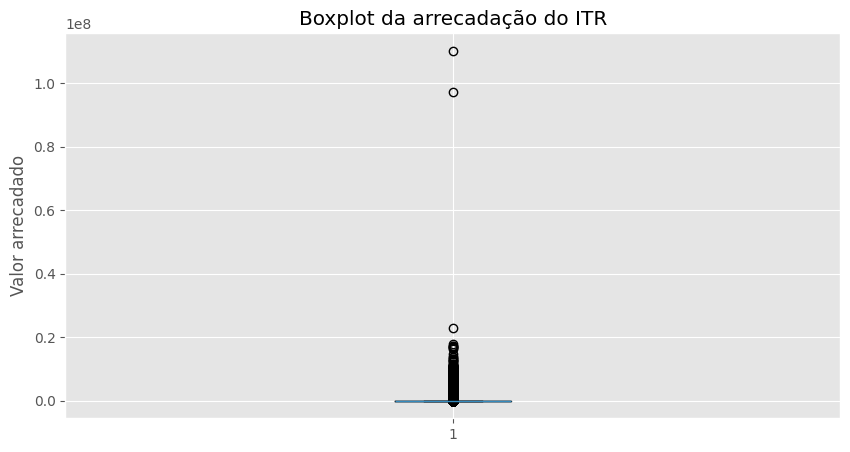

In [17]:
# Boxplot para verificar outliers

plt.figure(figsize=(10,5))

plt.boxplot(df['valor'])

plt.title('Boxplot da arrecadação do ITR')
plt.ylabel('Valor arrecadado')

plt.show()

# Etapa 3 — Análise Exploratória de Dados (EDA)

# Pergunta 1 — Quais estados arrecadaram mais ITR?

In [18]:
top_estados = (
    df.groupby('uf_sigla')['valor'].sum().sort_values(ascending=False)
)

top_estados.head(10)



uf_sigla
MS    3.026717e+09
SP    2.956904e+09
MT    2.793992e+09
GO    2.271304e+09
PR    2.045389e+09
MG    1.632398e+09
RS    1.563154e+09
BA    4.790936e+08
TO    3.580340e+08
SC    2.628583e+08
Name: valor, dtype: float64

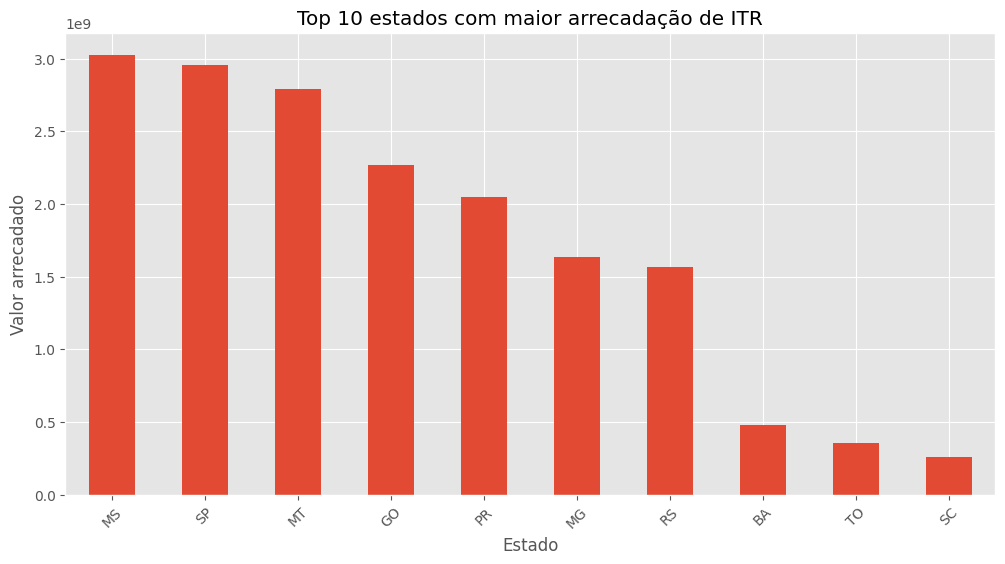

In [19]:
plt.figure(figsize=(12,6))

top_estados.head(10).plot(kind='bar')

plt.title('Top 10 estados com maior arrecadação de ITR')
plt.xlabel('Estado')
plt.ylabel('Valor arrecadado')
plt.xticks(rotation=45)

plt.savefig("../images/maior_arrecadacao_por_estado.png", dpi=300, bbox_inches="tight")

plt.show()

Os resultados mostram que a arrecadação do ITR está concentrada em determinados estados, com destaque para Mato Grosso do Sul, São Paulo e Mato Grosso.

Esses estados apresentam valores acumulados superiores aos das demais unidades federativas analisadas. Esse comportamento pode estar relacionado a fatores como extensão territorial, quantidade e valor das propriedades rurais e intensidade da atividade agropecuária.

Entretanto, seriam necessárias outras fontes de dados para avaliar a influência individual de cada fator.

# Pergunta 2 — A arrecadação aumentou ao longo dos anos?

In [20]:
arrecadacao_tempo = (
    df.groupby('ano')['valor'].sum()
)

arrecadacao_tempo

ano
2018    1.353956e+09
2019    1.419276e+09
2020    1.584678e+09
2021    1.951218e+09
2022    2.408155e+09
2023    2.870120e+09
2024    3.152287e+09
2025    3.660856e+09
2026    1.325573e+08
Name: valor, dtype: float64

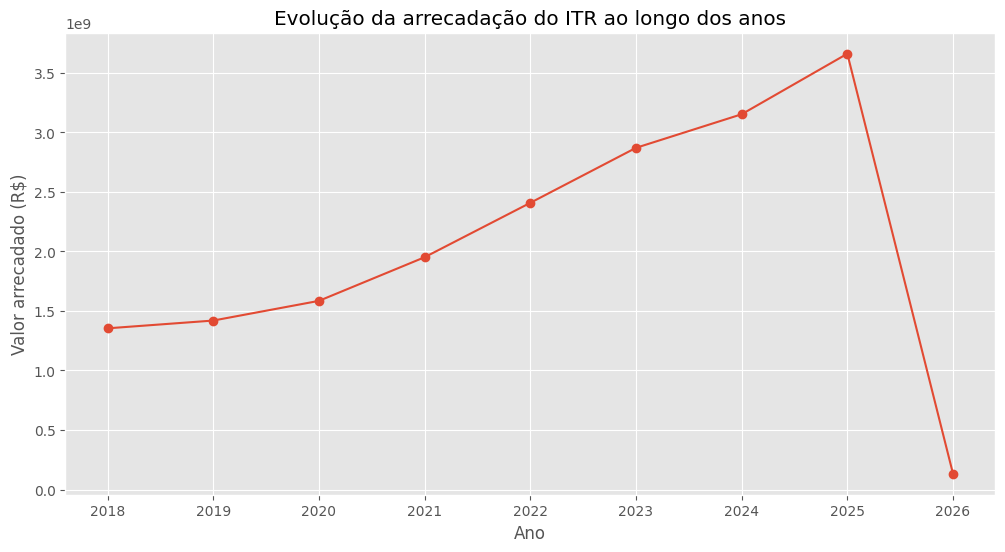

In [21]:
plt.figure(figsize=(12,6))

plt.plot(
    arrecadacao_tempo.index,
    arrecadacao_tempo.values,
    marker='o'
)

plt.title('Evolução da arrecadação do ITR ao longo dos anos')
plt.xlabel('Ano')
plt.ylabel('Valor arrecadado (R$)')
plt.grid(True)

plt.savefig("../images/evolucao_arrecadacao_itr.png", dpi=300, bbox_inches="tight")

plt.show()

Observa-se uma tendência de crescimento da arrecadação do ITR ao longo do período analisado, com aumento mais acentuado a partir de 2020.

O valor referente a 2026 apresenta uma redução significativa em comparação aos anos anteriores. Como os dados desse ano podem ainda não representar o período completo, o resultado deve ser interpretado com cautela.

# Pergunta 3 — Existe concentração regional de arrecadação?

In [22]:
regioes = (
    df.groupby('regiao')['valor'].sum().sort_values(ascending=False)
)

regioes

regiao
Centro-Oeste    8.104617e+09
Sudeste         4.721788e+09
Sul             3.871401e+09
Nordeste        1.064542e+09
Norte           7.707549e+08
Name: valor, dtype: float64

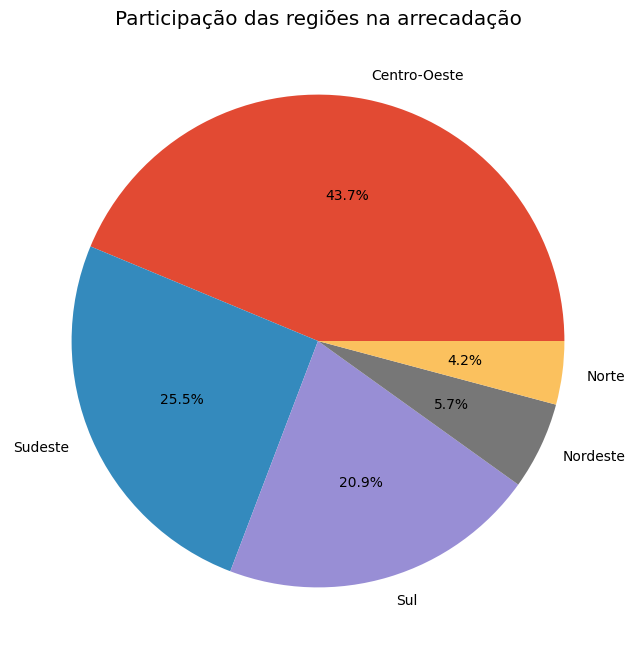

In [23]:
plt.figure(figsize=(8,8))

plt.pie(regioes,labels=regioes.index,autopct='%1.1f%%')

plt.title('Participação das regiões na arrecadação')

plt.savefig("../images/participacao_regioes.png", dpi=300, bbox_inches="tight")

plt.show()

A análise demonstra uma concentração relevante da arrecadação do ITR na região Centro-Oeste, seguida pelas regiões Sudeste e Sul.

Essa distribuição pode estar associada à extensão das áreas rurais, à quantidade de propriedades e às características econômicas das regiões. No entanto, a confirmação dessas relações exigiria a integração com outras fontes de dados.

# Pergunta 4 — Existe concentração e disparidade na arrecadação entre municípios?

In [24]:
top_cidades = (
    df.groupby('cidade')['valor'].sum().sort_values(ascending=False)
)

top_cidades.head(10)

cidade
Maracaju              1.432569e+08
Campo Grande          1.429051e+08
Corumbá               1.418680e+08
Ribas do Rio Pardo    1.378058e+08
Rio Verde             1.337528e+08
União dos Palmares    1.198883e+08
Coruripe              1.132916e+08
Ponta Porã            1.032299e+08
Jataí                 1.009620e+08
São Desidério         9.717552e+07
Name: valor, dtype: float64

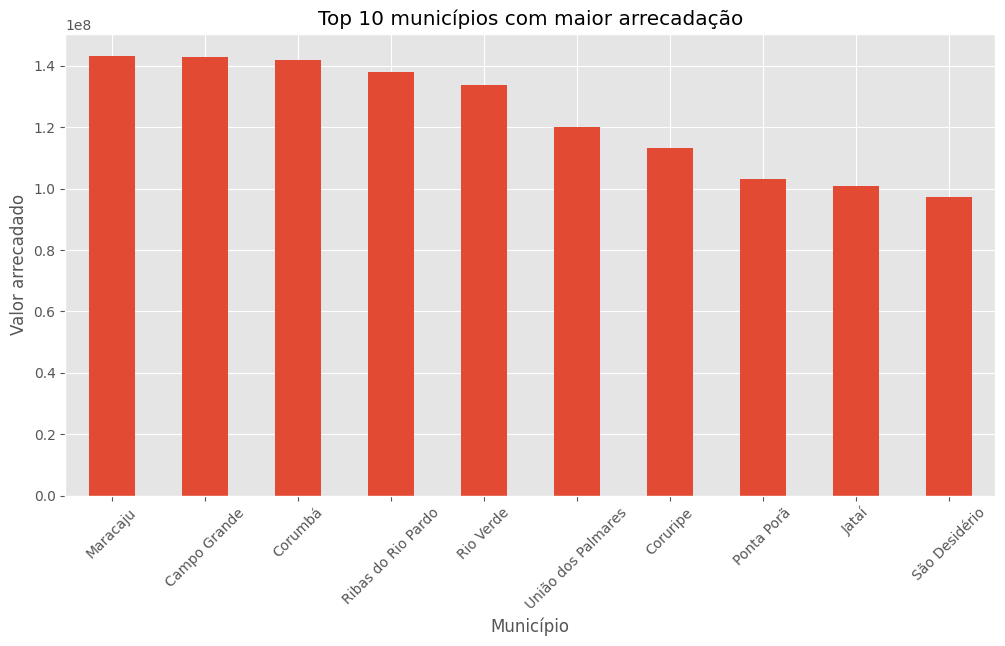

In [25]:
plt.figure(figsize=(12,6))

top_cidades.head(10).plot(kind='bar')

plt.title('Top 10 municípios com maior arrecadação')
plt.xlabel('Município')
plt.ylabel('Valor arrecadado')

plt.xticks(rotation=45)

plt.savefig("../images/maior_arrecadacao_por_cidade.png", dpi=300, bbox_inches="tight")

plt.show()

Os resultados indicam uma forte concentração da arrecadação em um grupo reduzido de municípios.

Maracaju, Campo Grande e Corumbá apresentam valores acumulados significativamente superiores aos da maior parte das cidades analisadas, evidenciando uma distribuição assimétrica da arrecadação municipal.

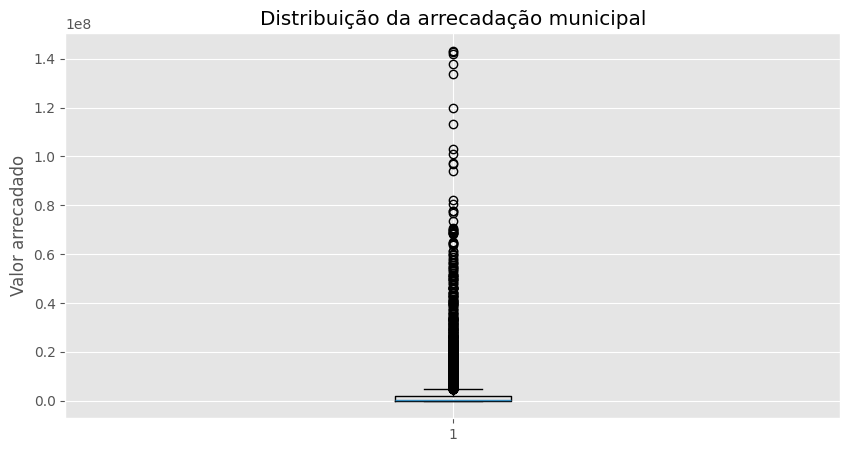

In [26]:
plt.figure(figsize=(10,5))

plt.boxplot(top_cidades)

plt.title('Distribuição da arrecadação municipal')
plt.ylabel('Valor arrecadado')

plt.savefig("../images/distribuicao_arrecadacao_municipal.png", dpi=300, bbox_inches="tight")

plt.show()

O boxplot reforça a presença de uma distribuição assimétrica, com grande diferença entre os valores arrecadados pelos municípios.

A presença de pontos distantes da maior concentração dos dados indica que alguns municípios possuem valores consideravelmente superiores aos demais. Esses registros não representam necessariamente erros, mas municípios com comportamento distinto dentro do conjunto analisado.

# Conclusões

A análise identificou uma distribuição concentrada da arrecadação do ITR entre estados, regiões e municípios. A região Centro-Oeste apresentou participação relevante, enquanto alguns estados e municípios concentraram valores significativamente superiores aos demais.

Também foi observada uma tendência de crescimento da arrecadação ao longo do período analisado. Entretanto, o resultado referente a 2026 deve ser interpretado com cautela, pois o ano pode não estar representado integralmente na base.

Os resultados sugerem que características territoriais, fundiárias e econômicas podem estar relacionadas às diferenças observadas. Contudo, a confirmação dessas relações exigiria a integração dos dados de arrecadação com outras informações, como área rural, quantidade de propriedades, produção agropecuária e valor da terra.

Como evolução futura, o projeto pode incluir novas fontes de dados, automatização do processo de tratamento e desenvolvimento de um dashboard interativo.